In [167]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from torchvision import datasets
from collections import Counter

In [168]:
import torch.nn as nn

In [169]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [170]:
train_dataset = datasets.ImageFolder('Data/NEU-DET/train/images')

Total classes and images per class

In [171]:
counter = Counter()
class_counts = Counter(train_dataset.targets)

print(f"Total Images: {len(train_dataset)}")
print(f"Image classes: {train_dataset.classes}")

for class_idx, class_name in enumerate(train_dataset.classes):
    print(f"{class_name}: {class_counts[class_idx]}")

Total Images: 1440
Image classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
crazing: 240
inclusion: 240
patches: 240
pitted_surface: 240
rolled-in_scale: 240
scratches: 240


Image information: Considering information from `crazing`

In [172]:
image, label = train_dataset[0]
print(f"Image Class: {train_dataset.classes[label]}")
print(f"Image Dimension: {image.size}")

Image Class: crazing
Image Dimension: (200, 200)


<h3>Image Normalization</h3> <br>
Normalization scales pixel values to a common range (such as 0–1 or −1 to 1) before training a CNN. It is important because it:

- Speeds up model convergence.
- Produces more stable gradients during backpropagation.
- Improves the efficiency of optimization algorithms.
- Prevents features with large values from dominating learning.
- Often leads to better accuracy and more stable training.

In [173]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # ensuring all images in grayscale format i.e B&W
    transforms.Resize((200,200)), # although images are already in dimension 200x200, ensuring it for all
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

`ImageFolder` stores the images data, their classes and all other required information regarding image data

In [174]:
train_dataset = datasets.ImageFolder(
    root='Data/NEU-DET/train/images',
    transform=transform
)

`DataLoader` feeds chunks of image data from every classes in a batch for training a model.

In [175]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True
)

In [176]:
# Validation dataset from folder (separate from train split)
val_dataset = datasets.ImageFolder(
    root='Data/NEU-DET/validation/images',
    transform=transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [177]:
images, label = next(iter(train_loader))

print(image.size)

(200, 200)


<h3>Building a CNN classifier </h3>

In [178]:
class CNN_classifier(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(

            # first convolution layer

            nn.Conv2d(
                in_channels=1, # since we have Grayscale image so defining channel size 1
                out_channels=32, # taking 32 kernels of 3x3 size
                kernel_size=3,  # selecting a kernel of 3x3 size
                stride=1, # stride slides scanning 1 step (1 step right, 1 step down and so on)
                padding=1, # padding adds an extra layer/border to prevent missing of important borderline features
                # for now extra padding of values 0 are assigned
            ),

            nn.ReLU(), # Applying ReLU activation to final feature matrix

            nn.MaxPool2d(
                kernel_size=2 , # using maxpool pooling with kernel 2x2
            ),

            # second convolution layer

            nn.Conv2d(
                in_channels=32, # since our input from previous conv layer is 100x100(with 32 kernel values)
                out_channels=64, # defining 64 kernels for conv. layer 2
                stride=1,
                kernel_size=3, # defining 3x3 kernel for conv. layer 2
                padding=1,
            ),

            nn.ReLU(), # again applying relu activation for conv. layer 2 feature matrix

            nn.MaxPool2d(2), # using max pooling with kernel size (2,2)

        )

        self.classifier = nn.Sequential(
            
            nn.Flatten(), # making the pixel in 1 dim

            nn.Linear(              # defining the fully-connected linear layer
                in_features=(50*50*64),
                out_features=128,
                bias=True,
            ),

            nn.ReLU(), # using Relu activation to add non-linearity

            nn.Linear(      # Again full-connected linear layer
            in_features=128,
            out_features=6   # since we have 6 image classes
            ),

        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


<h4>Model Architecture</h4> 

`Convolution Layer 1`

- Input size (`200x200`)
- Padding (1)
- Input size after padding (`202x202`)
- Kernel size (`3x3`)
- Number of kernels (`32`)
- stride (`1`)
- Feature Matrix size (`200x200x32`) 
- `Feature Matrix size = ((n-m+2(p) / stride) x (n-m+2(p) / stride))`
- Final feature size after pooling (`100x100x32`)

`Convolution layer 2`

- Input size (`100x100`)
- Padding (`1`)
- Input size after padding (`102x102`)
- kernel size (`3x3`)
- Number of kernel (`64`)
- stride (`1`)
- Feature Matrix size (`100x100x64`)
- Final size after pooling (`50x50x64`)

`Linearity`

- Fully connected linear layer with `160000` input and `128` output
- Relu activation
- Fully connected linear layer with `128` input and `6` output
- Final Relu activation

<h3>Training Pipeline</h3>

In [179]:
from torch.optim import Adam

In [180]:
model = CNN_classifier().to(device=device)
print(model.parameters)
EPOCHES = 15
criterion = nn.CrossEntropyLoss()   # using multi-class cross entropy loss
optimizer = Adam(params=model.parameters(), lr=0.001)  # taking learning rate 0.001

<bound method Module.parameters of CNN_classifier(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=160000, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=6, bias=True)
  )
)>


`Description of training pipeline`

- Taking the epoch value `15`.
- First, Training the model through a batch.
- Calculating the training loss and accuracy at each batch.
- After training through a batch, model is evaluated on shuffled batch with the same parameter it was trained.
- Then, Validation loss for each batch is calculated.
- Above steps are repeated upto `15` epoch.

In [181]:
torch.manual_seed(42)

In [182]:
LOSSES = []
TRAIN_LOSS = []
TRAIN_ACC = []
VAL_LOSS = []
VAL_ACC = []

for epoch in range (EPOCHES):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:   # Loading a batch of size 32

        # moving the image to GPU
        images = images.to(device)  
        labels = labels.to(device)

        # Reset gradients of all model parameters
        optimizer.zero_grad()

        # forward propagation
        predictions = model(images)

        # computing loss
        loss = criterion(predictions, labels)

        # Note: the model is producing the class of the images i.e label (for our case 0-5)
        # We do not compare the predictions with images (tensor of images)

        loss.backward()

        optimizer.step()    

        running_loss += loss.item() * images.size(0)  
        # we computed the running loss, since CrossEntropy returns mean of the loss, so (loss * batch_size)

        preds = predictions.argmax(dim=1) # predicted labels

        correct += (preds == labels).sum().item() # checking predicted labels == actual labels

        total += labels.size(0) 

    train_loss_epoch = running_loss / total  # training loss per epoch
    train_acc_epoch = correct / total  # training accuracy per epoch

    TRAIN_LOSS.append(train_loss_epoch)
    TRAIN_ACC.append(train_acc_epoch)
    LOSSES.append(train_loss_epoch)

    

    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()

            val_total += labels.size(0)

    val_loss = running_val_loss / val_total
    val_acc = val_correct / val_total

    VAL_LOSS.append(val_loss)
    VAL_ACC.append(val_acc)


    print(
    f"Epoch {epoch+1:2d} | "
    f"Train Loss: {train_loss_epoch:.4f} | "
    f"Val Loss: {val_loss:.4f} | "
    f"Train Acc: {train_acc_epoch:.4f} |"
    f"Val Acc: {val_acc:.4f}"
    )

Epoch  1 | Train Loss: 1.2808 | Val Loss: 0.4483 | Train Acc: 0.5639 |Val Acc: 0.8486
Epoch  2 | Train Loss: 0.5230 | Val Loss: 0.4518 | Train Acc: 0.8194 |Val Acc: 0.8466
Epoch  3 | Train Loss: 0.3533 | Val Loss: 0.4533 | Train Acc: 0.8694 |Val Acc: 0.8464
Epoch  4 | Train Loss: 0.2087 | Val Loss: 0.4539 | Train Acc: 0.9354 |Val Acc: 0.8464
Epoch  5 | Train Loss: 0.1824 | Val Loss: 0.4521 | Train Acc: 0.9486 |Val Acc: 0.8467
Epoch  6 | Train Loss: 0.1451 | Val Loss: 0.4529 | Train Acc: 0.9597 |Val Acc: 0.8461
Epoch  7 | Train Loss: 0.1678 | Val Loss: 0.4534 | Train Acc: 0.9444 |Val Acc: 0.8461
Epoch  8 | Train Loss: 0.1594 | Val Loss: 0.4518 | Train Acc: 0.9444 |Val Acc: 0.8462
Epoch  9 | Train Loss: 0.0975 | Val Loss: 0.4505 | Train Acc: 0.9715 |Val Acc: 0.8466
Epoch 10 | Train Loss: 0.0816 | Val Loss: 0.4481 | Train Acc: 0.9681 |Val Acc: 0.8472
Epoch 11 | Train Loss: 0.0519 | Val Loss: 0.4463 | Train Acc: 0.9854 |Val Acc: 0.8474
Epoch 12 | Train Loss: 0.0793 | Val Loss: 0.4580 | Tra

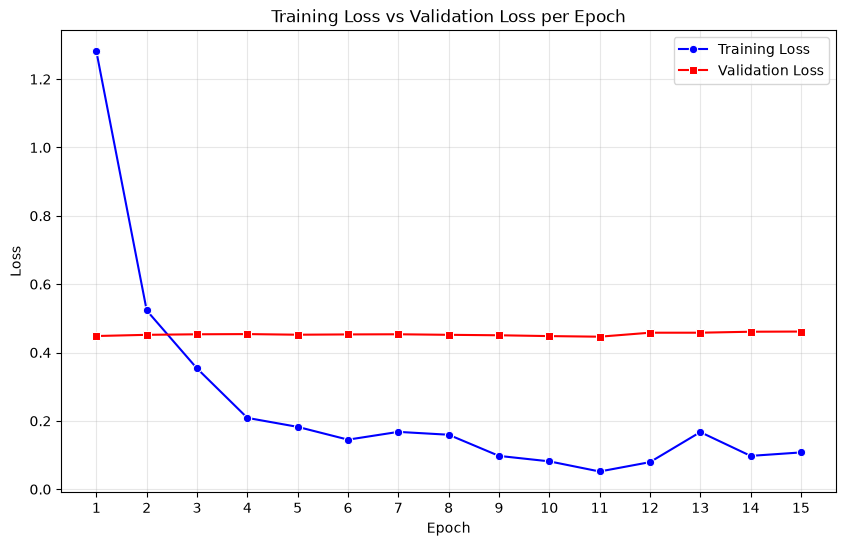

In [183]:
# Training loss vs Validation loss per epoch
epochs_axis = list(range(1, EPOCHES + 1))

plt.figure(figsize=(10, 6))
sns.lineplot(x=epochs_axis, y=TRAIN_LOSS, marker="o", label="Training Loss", c="b")
sns.lineplot(x=epochs_axis, y=VAL_LOSS, marker="s", label="Validation Loss", c="r")

plt.title("Training Loss vs Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_axis)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [184]:
from sklearn.metrics import f1_score, classification_report

# Validation F1 score
model.eval()
all_val_preds = []
all_val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_val_preds.extend(preds.cpu().numpy())
        all_val_labels.extend(labels.cpu().numpy())

f1_macro = f1_score(all_val_labels, all_val_preds, average="macro")
f1_weighted = f1_score(all_val_labels, all_val_preds, average="weighted")
f1_micro = f1_score(all_val_labels, all_val_preds, average="micro")

print(f"Validation F1 Score (Macro):    {f1_macro:.4f}")
print(f"Validation F1 Score (Weighted): {f1_weighted:.4f}")
print(f"Validation F1 Score (Micro):    {f1_micro:.4f}")

print("\nClass-wise report:")
print(classification_report(all_val_labels, all_val_preds, target_names=val_dataset.classes, digits=4))

Validation F1 Score (Macro):    0.8111
Validation F1 Score (Weighted): 0.8111
Validation F1 Score (Micro):    0.8167

Class-wise report:
                 precision    recall  f1-score   support

        crazing     0.8219    1.0000    0.9023        60
      inclusion     0.9118    0.5167    0.6596        60
        patches     1.0000    0.9167    0.9565        60
 pitted_surface     0.7910    0.8833    0.8346        60
rolled-in_scale     0.7879    0.8667    0.8254        60
      scratches     0.6615    0.7167    0.6880        60

       accuracy                         0.8167       360
      macro avg     0.8290    0.8167    0.8111       360
   weighted avg     0.8290    0.8167    0.8111       360



<b> Class `Inclusion` has lowest F1 score</b>       